   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Certifications  Publications  \
0                No       6.02       6.54  ...               2             0   
1               Yes       5.84       5.12  ...               1             0   
2                No       4.91       5.29  ...               1             0   
3                No       7.67       8.03  ...               2             0   
4                No       8.14       8.97  ...               4             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockI

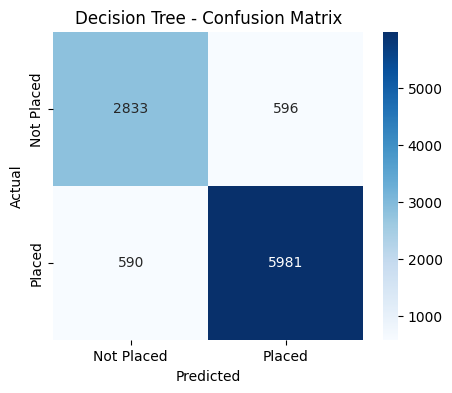

In [2]:
# Decision Tree - Placement Dataset Classification

## Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Load Placement dataset

df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")

# Display first 5 rows
print(df.head())


# Remove StudentID column because it is only an ID

df = df.drop("StudentID", axis=1)


# Convert categorical columns into numerical values

label_encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])


# Input features

X = df.drop("PlacementStatus", axis=1)


# Target variable

y = df["PlacementStatus"]


# Binary Classification
# PlacementStatus:
# 0 = Not Placed
# 1 = Placed


# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Step 2: Train the Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)


# Predictions

y_pred = model.predict(X_test)


## Step 3: Model Evaluation

acc = accuracy_score(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)


print("Accuracy:", acc)

print("Confusion Matrix:\n", conf_matrix)

print("Classification Report:\n", classification_report(y_test, y_pred))


# Plot Confusion Matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Decision Tree - Confusion Matrix')

plt.show()

Dataset Shape: (50000, 31)

Dataset Columns:
Index(['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream',
       'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1',
       'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6',
       'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships',
       'Projects', 'Workshops', 'Certifications', 'Publications',
       'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore',
       'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus',
       'IsAnomaly'],
      dtype='object')

Classes: Not Placed (0), Placed (1)

===== GINI DECISION TREE =====
Accuracy: 0.8837

Confusion Matrix:
[[2824  605]
 [ 558 6013]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.84      0.82      0.83      3429
      Placed       0.91      0.92      0.91      6571

    accuracy                           0.88     10000
   macro avg       0.87      0.87      0.87 

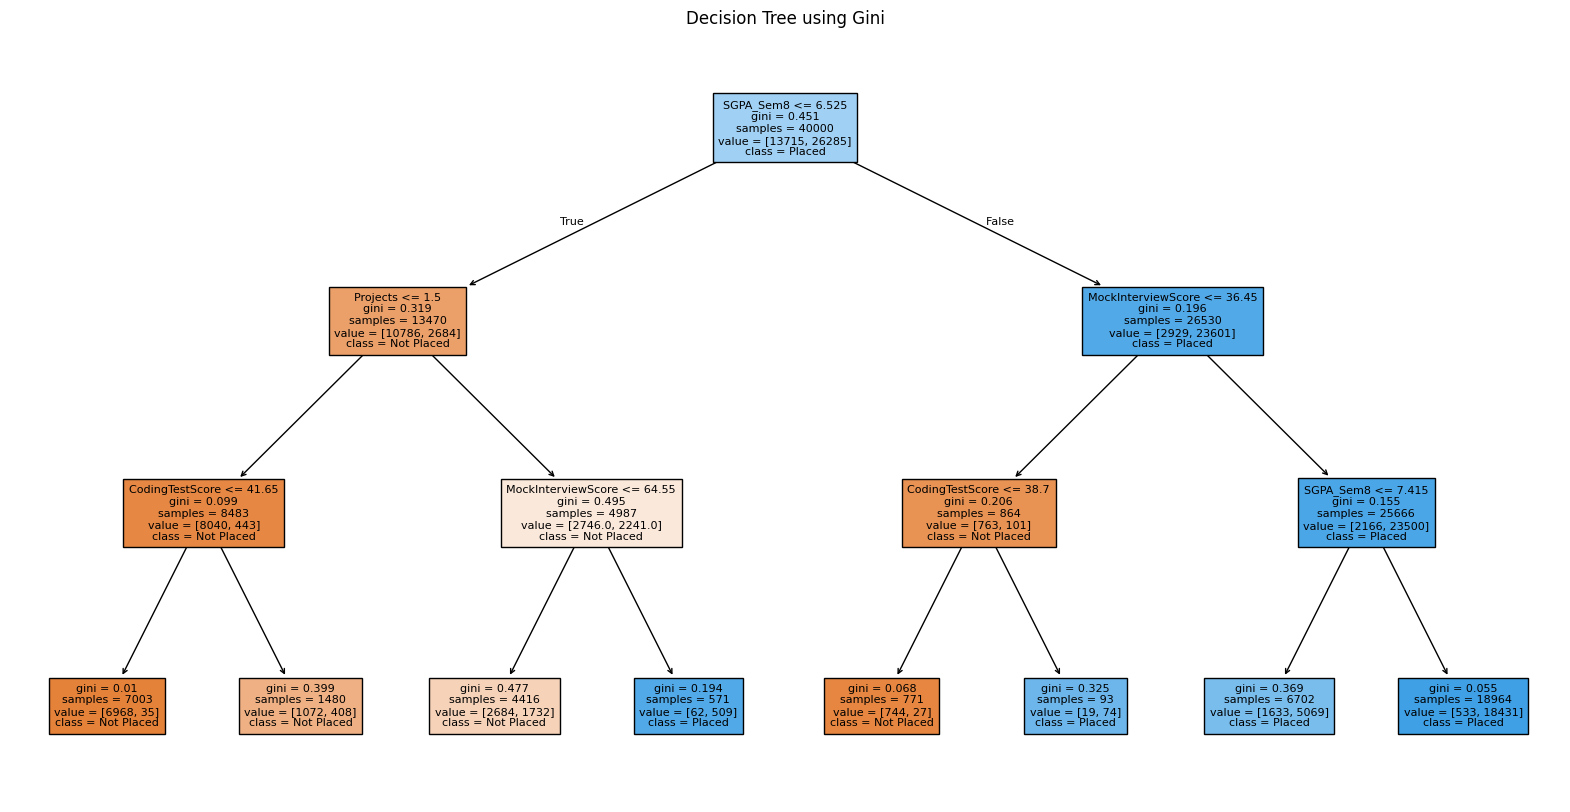


===== ENTROPY DECISION TREE =====
Accuracy: 0.8714

Confusion Matrix:
[[2335 1094]
 [ 192 6379]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.92      0.68      0.78      3429
      Placed       0.85      0.97      0.91      6571

    accuracy                           0.87     10000
   macro avg       0.89      0.83      0.85     10000
weighted avg       0.88      0.87      0.87     10000



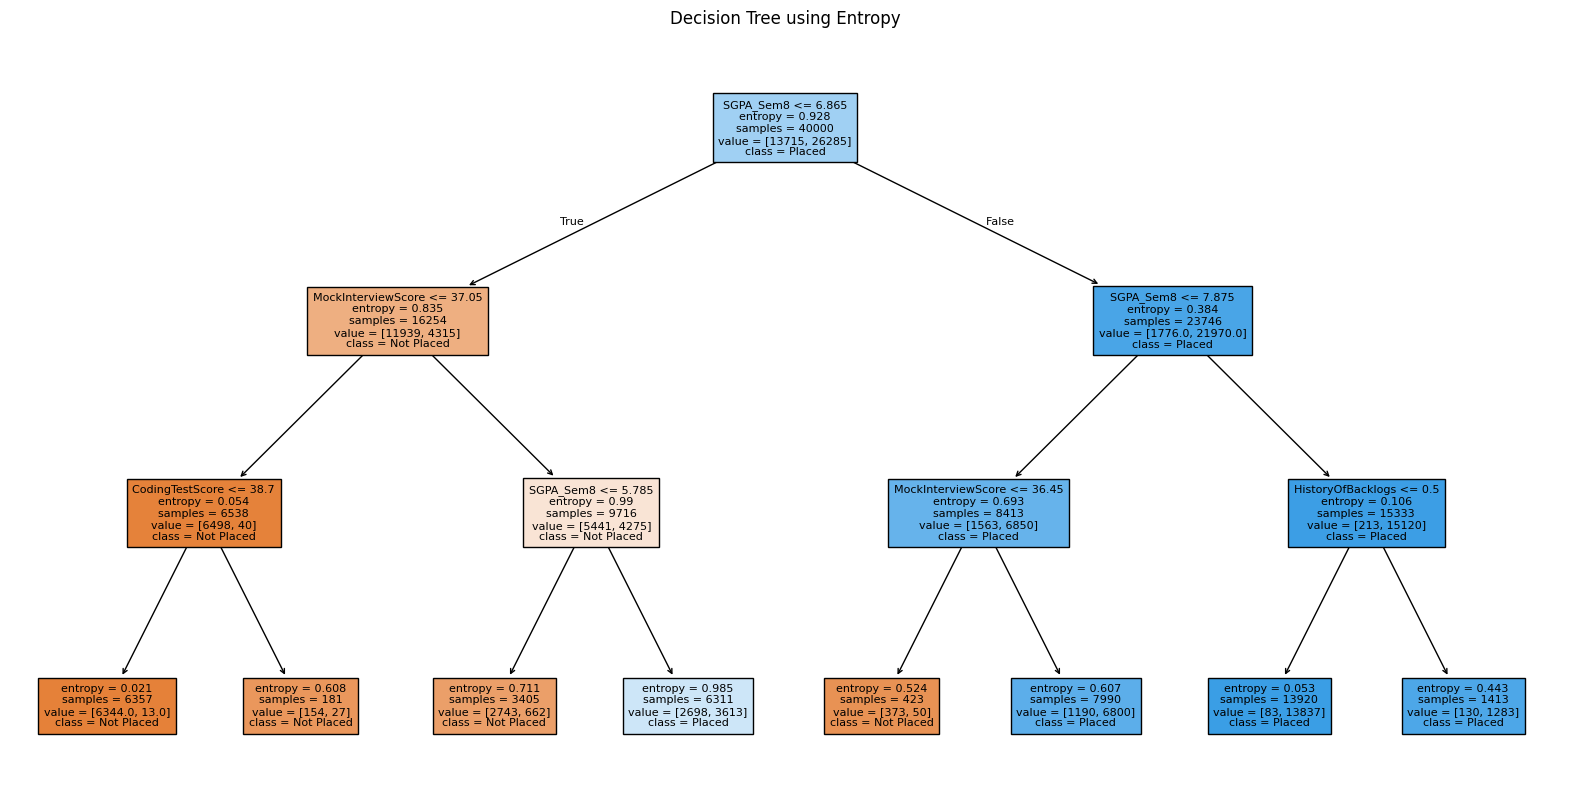


===== GINI vs ENTROPY =====
  Criterion  Accuracy
0      Gini    0.8837
1   Entropy    0.8714

===== MAX DEPTH RESULTS =====
   Max Depth  Gini Train Accuracy  Gini Test Accuracy  Entropy Train Accuracy  \
0          1             0.859675              0.8538                0.847725   
1          2             0.876225              0.8695                0.847725   
2          3             0.888775              0.8837                0.878675   
3          4             0.895175              0.8907                0.894575   
4          5             0.905925              0.8979                0.896525   
5          6             0.915025              0.9051                0.909050   
6          7             0.919425              0.9056                0.912375   
7          8             0.923925              0.9030                0.916500   
8          9             0.931025              0.9059                0.925250   
9         10             0.939175              0.9022           

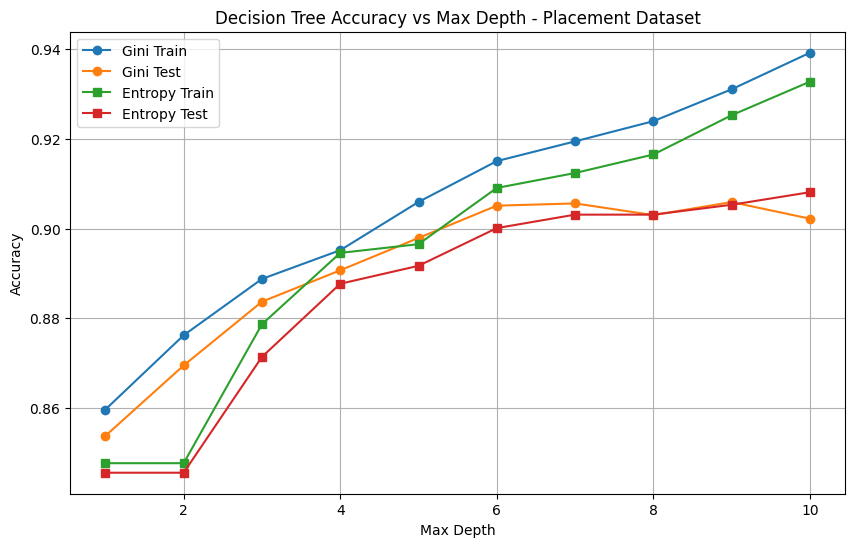

In [5]:
# Decision Tree with Depth Limit and Different Attributes
# Placement Dataset Classification
# Binary Classification
# Gini vs Entropy + Max Depth


# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree


# ==========================================================
# Step 2: Load Placement Dataset
# ==========================================================

df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")

print("Dataset Shape:", df.shape)

print("\nDataset Columns:")
print(df.columns)


# Remove StudentID because it is only an identifier

df = df.drop("StudentID", axis=1)


# Convert categorical columns into numerical values

label_encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])


# Input Features

X = df.drop("PlacementStatus", axis=1)


# Target Variable

y = df["PlacementStatus"]


print("\nClasses: Not Placed (0), Placed (1)")


# ==========================================================
# Step 3: Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================================
# Step 4: Decision Tree using Gini
# ==========================================================

gini_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

gini_model.fit(X_train, y_train)

y_pred_gini = gini_model.predict(X_test)


print("\n===== GINI DECISION TREE =====")

print("Accuracy:", accuracy_score(y_test, y_pred_gini))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gini))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_gini,
    target_names=["Not Placed", "Placed"]
))


# Plot Gini Tree

plt.figure(figsize=(20, 10))

plot_tree(
    gini_model,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    fontsize=8
)

plt.title("Decision Tree using Gini")
plt.show()


# ==========================================================
# Step 5: Decision Tree using Entropy
# ==========================================================

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

entropy_model.fit(X_train, y_train)

y_pred_entropy = entropy_model.predict(X_test)


print("\n===== ENTROPY DECISION TREE =====")

print("Accuracy:", accuracy_score(y_test, y_pred_entropy))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_entropy))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_entropy,
    target_names=["Not Placed", "Placed"]
))


# Plot Entropy Tree

plt.figure(figsize=(20, 10))

plot_tree(
    entropy_model,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    fontsize=8
)

plt.title("Decision Tree using Entropy")
plt.show()


# ==========================================================
# Step 6: Compare Gini and Entropy
# ==========================================================

gini_accuracy = accuracy_score(y_test, y_pred_gini)

entropy_accuracy = accuracy_score(y_test, y_pred_entropy)


comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [gini_accuracy, entropy_accuracy]
})


print("\n===== GINI vs ENTROPY =====")
print(comparison)


# ==========================================================
# Step 7: Effect of Max Depth
# ==========================================================

depth_results = []


for depth in range(1, 11):

    # Gini Model

    model_gini = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model_gini.fit(X_train, y_train)

    train_acc_gini = model_gini.score(X_train, y_train)

    test_acc_gini = model_gini.score(X_test, y_test)


    # Entropy Model

    model_entropy = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )

    model_entropy.fit(X_train, y_train)

    train_acc_entropy = model_entropy.score(X_train, y_train)

    test_acc_entropy = model_entropy.score(X_test, y_test)


    # Store Results

    depth_results.append([
        depth,
        train_acc_gini,
        test_acc_gini,
        train_acc_entropy,
        test_acc_entropy
    ])


# Create DataFrame for Results

depth_df = pd.DataFrame(
    depth_results,
    columns=[
        "Max Depth",
        "Gini Train Accuracy",
        "Gini Test Accuracy",
        "Entropy Train Accuracy",
        "Entropy Test Accuracy"
    ]
)


print("\n===== MAX DEPTH RESULTS =====")
print(depth_df)


# ==========================================================
# Step 8: Plot Accuracy vs Max Depth
# ==========================================================

plt.figure(figsize=(10, 6))


plt.plot(
    depth_df["Max Depth"],
    depth_df["Gini Train Accuracy"],
    marker="o",
    label="Gini Train"
)


plt.plot(
    depth_df["Max Depth"],
    depth_df["Gini Test Accuracy"],
    marker="o",
    label="Gini Test"
)


plt.plot(
    depth_df["Max Depth"],
    depth_df["Entropy Train Accuracy"],
    marker="s",
    label="Entropy Train"
)


plt.plot(
    depth_df["Max Depth"],
    depth_df["Entropy Test Accuracy"],
    marker="s",
    label="Entropy Test"
)


plt.xlabel("Max Depth")

plt.ylabel("Accuracy")

plt.title("Decision Tree Accuracy vs Max Depth - Placement Dataset")

plt.legend()

plt.grid(True)

plt.show()